In [ ]:
# BLOCK 1: Setup and Install Dependencies (UNCHANGED)
!pip install kaggle -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling3D, Conv3D, Dense, Flatten, Dropout, LSTM, TimeDistributed, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import roc_curve, auc
from google.colab import files
from tensorflow.keras.layers import Bidirectional
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")



TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# BLOCK 2: Setup Kaggle API and Download Dataset (UNCHANGED)
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Use KaggleHub to download CAUCAFall dataset
!pip install kagglehub -q
import kagglehub

print("Downloading CAUCAFall dataset...")
path = kagglehub.dataset_download("tuyenldvn/caucafall")

print("✅ Dataset downloaded and extracted at:", path)


Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


100%|██████████| 7.76G/7.76G [01:44<00:00, 79.6MB/s]

Extracting files...


✅ Dataset downloaded and extracted at: /root/.cache/kagglehub/datasets/tuyenldvn/caucafall/versions/2


In [ ]:
# BLOCK 3: Explore Dataset Structure (UNCHANGED)
data_dir = '/root/.cache/kagglehub/datasets/tuyenldvn/caucafall/versions/2/Dataset CAUCAFall/CAUCAFall'
print("Dataset structure (Sample):")

if not os.path.exists(data_dir):
    print(f"ERROR: The data directory path was not found: {data_dir}")
else:
    for root, dirs, files in os.walk(data_dir):
        level = root.replace(data_dir, '').count(os.sep)
        indent = ' ' * 2 * level

        if level <= 2:
            print(f'{indent}📂 {os.path.basename(root)}/')
            subindent = ' ' * 2 * (level + 1)
            for file in sorted(files)[:2]:
                print(f'{subindent}📄 {file}')
            if len(files) > 2:
                print(f'{subindent}... and {len(files)-2} more files')
        elif level == 3:
            print(f'{indent} ... (Further depth skipped)')

Dataset structure (Sample):
📂 CAUCAFall/
  📂 Subject.1/
    📂 Kneel/
      📄 KneelS1.avi
      📄 ars100001.png
      ... and 440 more files
    📂 Fall backwards/
      📄 FallBackwardsS1.avi
      📄 cas100001.png
      ... and 252 more files
    📂 Hop/
      📄 HopS1.avi
      📄 classes.txt
      ... and 366 more files
    📂 Fall left/
      📄 FallLeftS1.avi
      📄 cis100001.png
      ... and 174 more files
    📂 Walk/
      📄 WalkS1.avi
      📄 cams100001.png
      ... and 486 more files
    📂 Fall forward/
      📄 FallForwardS1.avi
      📄 cfs1-00001.png
      ... and 382 more files
    📂 Fall sitting/
      📄 FallSittingS1.avi
      📄 classes.txt
      ... and 366 more files
    📂 Sit down/
      📄 SitDownS1.avi
      📄 classes.txt
      ... and 376 more files
    📂 Fall right/
      📄 FallRightS1.avi
      📄 cds100001.png
      ... and 230 more files
    📂 Pick up object/
      📄 PickupobjectS1.avi
      📄 classes.txt
      ... and 236 more files
  📂 Subject.2/
    📂 Kneel/
      📄 

In [ ]:
# BLOCK 4: Data Loading and Preprocessing Functions (UNCHANGED)
IMG_SIZE = 64
SEQUENCE_LENGTH = 30
BATCH_SIZE = 8

def load_frame_sequence(folder_path, max_frames=SEQUENCE_LENGTH):
    """Load and preprocess a sequence of image frames from a folder"""
    frame_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')])
    frames = []

    total_frames = len(frame_files)
    if total_frames == 0:
        return np.zeros((max_frames, IMG_SIZE, IMG_SIZE, 3))

    frame_indices = np.linspace(0, total_frames - 1, max_frames, dtype=int)

    for idx in frame_indices:
        file_path = os.path.join(folder_path, frame_files[idx])
        frame = cv2.imread(file_path)

        if frame is not None:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame / 255.0
            frames.append(frame)
        else:
            if frames:
                frames.append(frames[-1])
            else:
                frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    while len(frames) < max_frames:
        frames.append(frames[-1] if frames else np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    return np.array(frames[:max_frames])


In [ ]:

# BLOCK 5: Create Dataset with Subject-Level Splitting (FIXED - MAJOR CHANGE)
def create_dataset_with_subjects(base_path):
    """
    Create dataset grouped by subject to prevent data leakage
    """
    subject_data = {}  # {subject_id: [(sequence_path, label), ...]}

    FALL_ACTIVITIES = ['fall backwards', 'fall forward', 'fall left', 'fall right', 'fall sitting']

    for root, dirs, files in os.walk(base_path):
        current_dir_name = os.path.basename(root).lower()

        # Check if folder contains PNG files (actual sequence)
        if any(f.endswith('.png') for f in files):

            # Extract subject ID from path
            path_parts = root.split(os.sep)
            subject_id = None

            # Find the part that contains "Subject" or similar
            for part in path_parts:
                if 'subject' in part.lower() or (part.startswith('S') and len(part) <= 10):
                    subject_id = part
                    break

            if subject_id is None:
                print(f"⚠️ Could not extract subject from: {root}")
                continue

            # Determine label
            is_fall = any(activity in current_dir_name for activity in FALL_ACTIVITIES)
            label = 1 if is_fall else 0

            # Group by subject
            if subject_id not in subject_data:
                subject_data[subject_id] = []
            subject_data[subject_id].append((root, label))

    return subject_data


# Load data grouped by subject
data_path = data_dir
subject_data = create_dataset_with_subjects(data_path)

print(f"\n📊 Dataset Summary:")
print(f"Total subjects: {len(subject_data)}")
for subject, sequences in list(subject_data.items())[:5]:  # Show first 5
    falls = sum(1 for _, label in sequences if label == 1)
    print(f"  {subject}: {len(sequences)} sequences ({falls} falls, {len(sequences)-falls} not-falls)")

# Split by SUBJECT (not by individual sequences!)
subjects = list(subject_data.keys())
train_subjects, temp_subjects = train_test_split(
    subjects, test_size=0.3, random_state=42
)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=0.5, random_state=42
)

# Now collect sequences for each split
X_train_paths, y_train = [], []
X_val_paths, y_val = [], []
X_test_paths, y_test = [], []

for subject in train_subjects:
    for path, label in subject_data[subject]:
        X_train_paths.append(path)
        y_train.append(label)

for subject in val_subjects:
    for path, label in subject_data[subject]:
        X_val_paths.append(path)
        y_val.append(label)

for subject in test_subjects:
    for path, label in subject_data[subject]:
        X_test_paths.append(path)
        y_test.append(label)

print(f"\n✅ Subject-Level Split (NO DATA LEAKAGE):")
print(f"Training: {len(X_train_paths)} sequences from {len(train_subjects)} subjects")
print(f"Validation: {len(X_val_paths)} sequences from {len(val_subjects)} subjects")
print(f"Testing: {len(X_test_paths)} sequences from {len(test_subjects)} subjects")
print(f"\nTrain subjects: {sorted(train_subjects)}")
print(f"Val subjects: {sorted(val_subjects)}")
print(f"Test subjects: {sorted(test_subjects)}")
print(f"\nClass distribution:")
print(f"Train - Falls: {sum(y_train)}, Not-falls: {len(y_train)-sum(y_train)}")
print(f"Val   - Falls: {sum(y_val)}, Not-falls: {len(y_val)-sum(y_val)}")
print(f"Test  - Falls: {sum(y_test)}, Not-falls: {len(y_test)-sum(y_test)}")





📊 Dataset Summary:
Total subjects: 10
  Subject.1: 10 sequences (5 falls, 5 not-falls)
  Subject.2: 10 sequences (5 falls, 5 not-falls)
  Subject.6: 10 sequences (5 falls, 5 not-falls)
  Subject.7: 10 sequences (5 falls, 5 not-falls)
  Subject.8: 10 sequences (5 falls, 5 not-falls)

✅ Subject-Level Split (NO DATA LEAKAGE):
Training: 70 sequences from 7 subjects
Validation: 10 sequences from 1 subjects
Testing: 20 sequences from 2 subjects

Train subjects: ['Subject.1', 'Subject.10', 'Subject.3', 'Subject.4', 'Subject.6', 'Subject.7', 'Subject.8']
Val subjects: ['Subject.5']
Test subjects: ['Subject.2', 'Subject.9']

Class distribution:
Train - Falls: 35, Not-falls: 35
Val   - Falls: 5, Not-falls: 5
Test  - Falls: 10, Not-falls: 10


In [ ]:
# BLOCK 6: Load Videos into Memory (UNCHANGED)
def load_videos_batch(video_paths, labels):
    """Load frame sequences in batch with progress bar"""
    X = []
    y = []

    for path, label in tqdm(zip(video_paths, labels), total=len(video_paths), desc="Loading sequences"):
        try:
            frames = load_frame_sequence(path)
            X.append(frames)
            y.append(label)
        except Exception as e:
            print(f"Error loading sequence from {path}: {e}")

    return np.array(X), np.array(y)

print("Loading training data...")
X_train, y_train = load_videos_batch(X_train_paths, y_train)

print("Loading validation data...")
X_val, y_val = load_videos_batch(X_val_paths, y_val)

print("Loading test data...")
X_test, y_test = load_videos_batch(X_test_paths, y_test)

print(f"\nData shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")




Loading training data...


Loading sequences: 100%|██████████| 70/70 [00:28<00:00,  2.48it/s]


Loading validation data...


Loading sequences: 100%|██████████| 10/10 [00:03<00:00,  3.25it/s]


Loading test data...


Loading sequences: 100%|██████████| 20/20 [00:05<00:00,  3.44it/s]


Data shapes:
X_train: (70, 30, 64, 64, 3), y_train: (70,)
X_val: (10, 30, 64, 64, 3), y_val: (10,)
X_test: (20, 30, 64, 64, 3), y_test: (20,)


Fall Example:


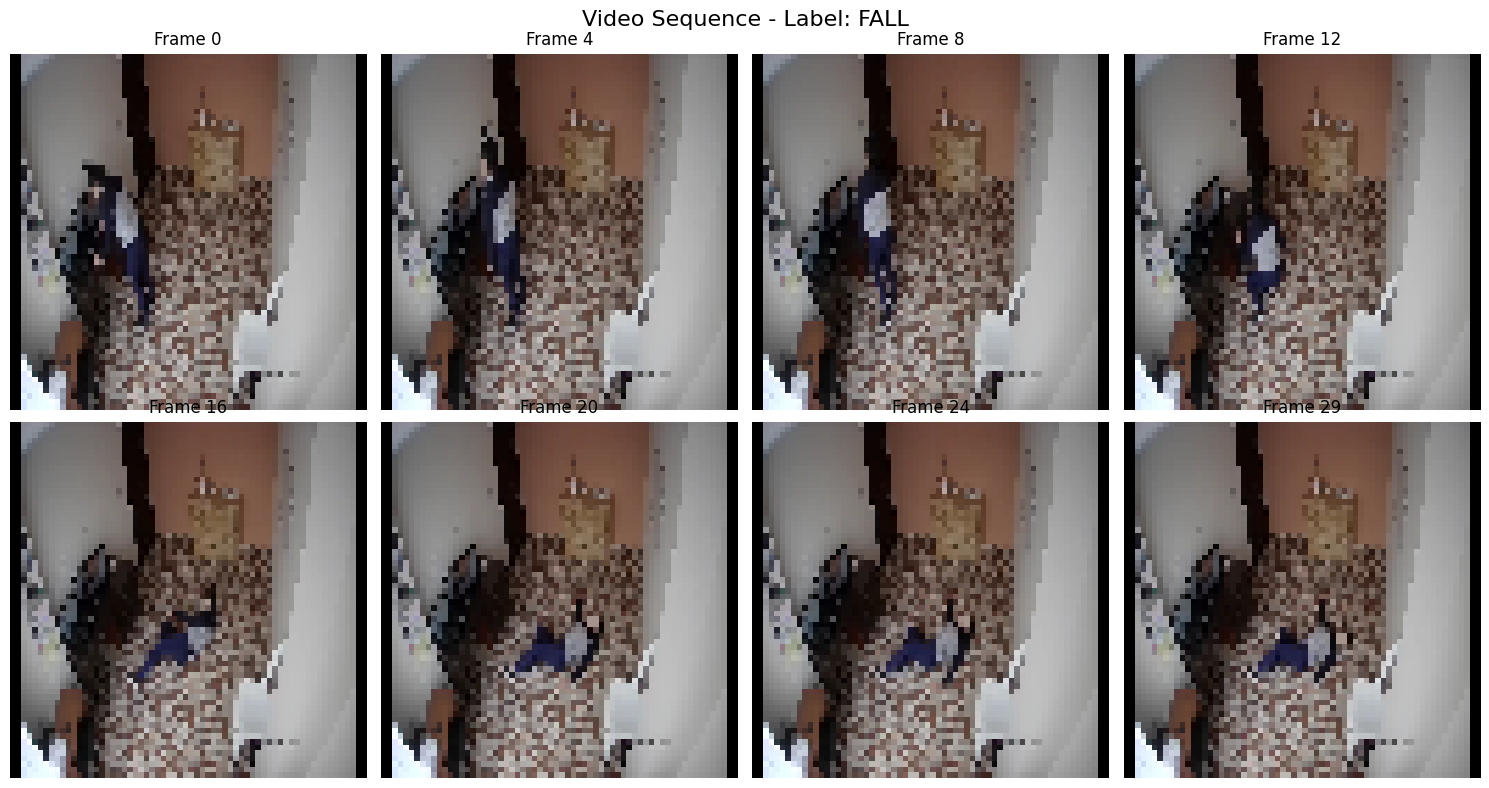


Not Fall Example:


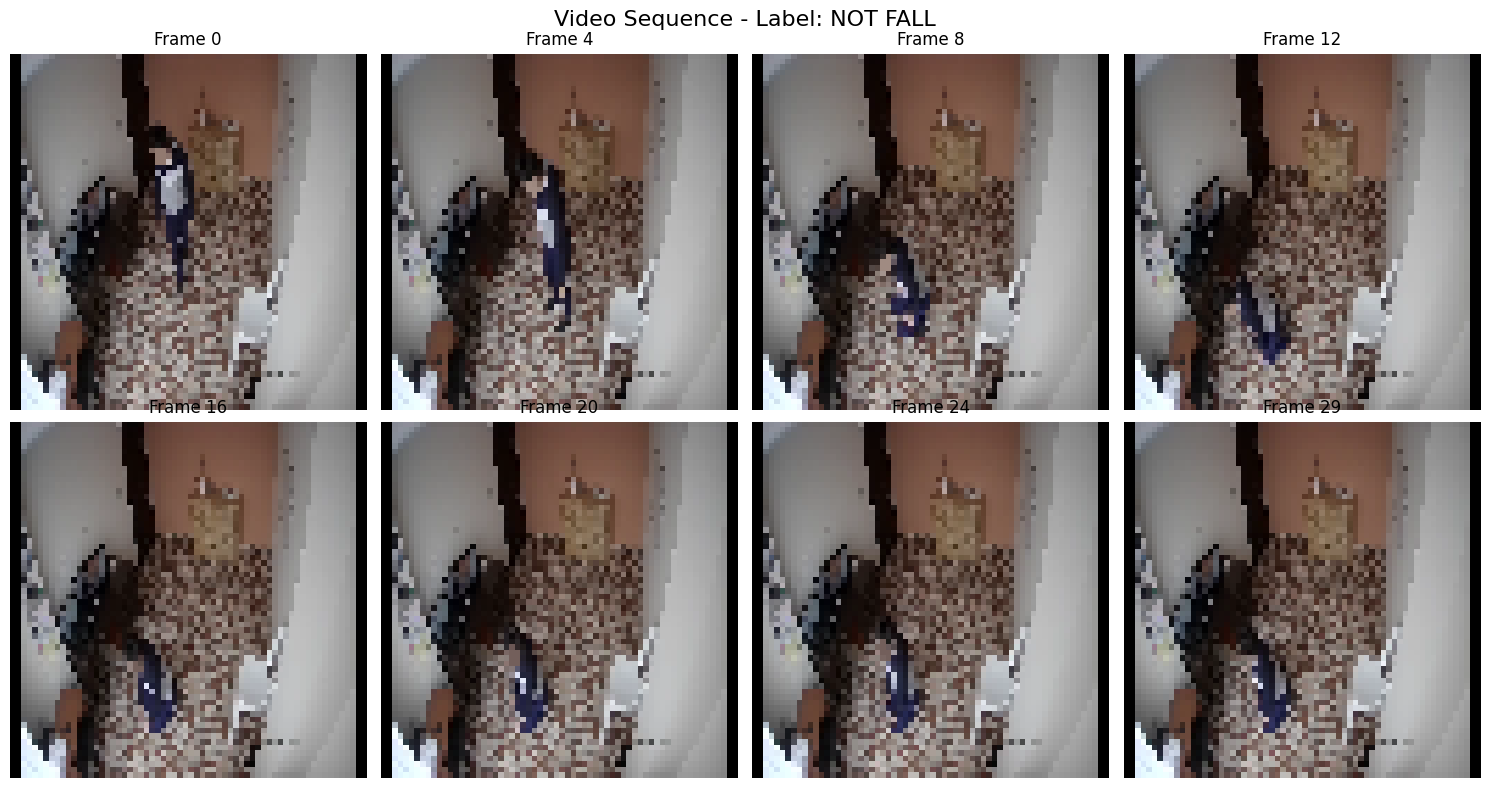

In [ ]:

# BLOCK 7: Visualize Sample Data (UNCHANGED)
def visualize_video_sequence(video_sequence, label, num_frames=8):
    """Visualize frames from a video sequence"""
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.flatten()

    frame_indices = np.linspace(0, len(video_sequence)-1, num_frames, dtype=int)

    for i, idx in enumerate(frame_indices):
        axes[i].imshow(video_sequence[idx])
        axes[i].axis('off')
        axes[i].set_title(f'Frame {idx}')

    label_text = "FALL" if label == 1 else "NOT FALL"
    fig.suptitle(f'Video Sequence - Label: {label_text}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize one fall and one not-fall example
fall_idx = np.where(y_train == 1)[0][0]
notfall_idx = np.where(y_train == 0)[0][0]

print("Fall Example:")
visualize_video_sequence(X_train[fall_idx], y_train[fall_idx])

print("\nNot Fall Example:")
visualize_video_sequence(X_train[notfall_idx], y_train[notfall_idx])



In [ ]:

# BLOCK 8: Build 3D CNN Model (UNCHANGED)
def build_3dcnn_model(input_shape):
    """Build 3D CNN model for spatiotemporal feature learning"""
    model = Sequential([
        # First 3D Conv Block
        Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same',
               input_shape=input_shape),
        MaxPooling3D(pool_size=(2, 2, 2)),
        Dropout(0.25),

        # Second 3D Conv Block
        Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        MaxPooling3D(pool_size=(2, 2, 2)),
        Dropout(0.25),

        # Third 3D Conv Block
        Conv3D(128, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        MaxPooling3D(pool_size=(2, 2, 2)),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    return model

# Build model
input_shape = (SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
model_3dcnn = build_3dcnn_model(input_shape)

model_3dcnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_3dcnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 30, 64, 64, 32) │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 15, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 15, 32, 32, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 7, 16, 16, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 16, 16, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 7, 16, 16, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 3, 8, 8, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 8, 8, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,291,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,604,033 (25.19 MB)

 Trainable params: 6,604,033 (25.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# BLOCK 9: Build CNN-LSTM Model (MODIFIED)
def build_cnn_lstm_model(input_shape):
    """Build CNN-LSTM model for spatiotemporal feature learning"""
    model = Sequential([
        # TimeDistributed CNN for spatial features (KEEP CONV LAYERS THE SAME)
        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                        input_shape=input_shape),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Flatten()),

        # LSTM for temporal features (SIMPLIFIED & REGULARIZED)
        # Use a single, larger LSTM layer instead of two stacked ones
        LSTM(256, dropout=0.5, recurrent_dropout=0.5), # Added dropout and recurrent dropout

        # Dense layers (simplified to one layer before output)
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    return model

# Build CNN-LSTM model
model_cnn_lstm = build_cnn_lstm_model(input_shape)

model_cnn_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_cnn_lstm.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 64, 64, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 30, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 30, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 30, 16, 16,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 30, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 30, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 30, 8192)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │     8,651,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,778,049 (33.49 MB)

 Trainable params: 8,778,049 (33.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# BLOCK 9B: Build Bi-LSTM Model
# ============================================================================
# Conceptual Advantage: Processes sequences FORWARD and BACKWARD
# Falls have context before (losing balance) and after (on ground)
# Bi-LSTM captures both directions simultaneously

def build_bilstm_model(input_shape):
    """
    Build Bidirectional LSTM model for spatiotemporal feature learning

    Architecture: CNN (spatial) → Bi-LSTM (temporal bidirectional) → Dense

    Why Bi-LSTM over LSTM:
    - Standard LSTM: Only sees past frames (1→30)
    - Bi-LSTM: Sees both past AND future frames (1→30 AND 30→1)
    - Better context for fall detection (pre-fall + post-fall signals)
    """
    model = Sequential([
        # TimeDistributed CNN for spatial features (SAME AS LSTM MODEL)
        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                        input_shape=input_shape),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Dropout(0.25)),

        TimeDistributed(Flatten()),

        # Bi-LSTM for bidirectional temporal features
        # Note: Bidirectional doubles the output (128*2 = 256)
        Bidirectional(LSTM(128, dropout=0.5, recurrent_dropout=0.5)),

        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    return model

# Build Bi-LSTM model
print("="*60)
print("BUILDING BI-LSTM MODEL")
print("="*60)

model_bilstm = build_bilstm_model(input_shape)

model_bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_bilstm.summary()



BUILDING BI-LSTM MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_20             │ (None, 30, 64, 64, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_21             │ (None, 30, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_22             │ (None, 30, 32, 32, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_23             │ (None, 30, 32, 32, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_24             │ (None, 30, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_25             │ (None, 30, 16, 16, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_26             │ (None, 30, 16, 16,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_27             │ (None, 30, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_28             │ (None, 30, 8, 8, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_29             │ (None, 30, 8192)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │     8,520,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,646,977 (32.99 MB)

 Trainable params: 8,646,977 (32.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# BLOCK 9C: Build Transformer Model (Pure Attention)
# ============================================================================
# Conceptual Advantage: Self-attention learns which frames matter most
# Processes all frames in parallel (faster than LSTM)
# Better at long-range dependencies

# TRANSFORMER HYPERPARAMETERS (ADJUSTABLE)
# ==========================================
NUM_HEADS = 4  # Number of attention heads (Must divide embedding_dim evenly)
NUM_LAYERS = 1     # Number of transformer encoder blocks
FFN_DIM = 256      # Feed-forward network dimension
DROPOUT_RATE = 0.3   # Dropout rate for regularization


def build_transformer_model(input_shape, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
              ffn_dim=FFN_DIM, dropout_rate=DROPOUT_RATE):
  """
  Build Transformer model for spatiotemporal feature learning

  Architecture: CNN (spatial) → Projection (dimensionality reduction) → Transformer Encoder (attention) → Dense

  FIX for OOM: Added a TimeDistributed(Dense) layer to reduce the embedding dimension
    from 8192 down to 512 before the Transformer block.
  """

  # Input layer
  inputs = layers.Input(shape=input_shape)

  # TimeDistributed CNN for spatial features (SAME AS LSTM)
  x = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(inputs)
  x = TimeDistributed(MaxPooling2D((2, 2)))(x)
  x = TimeDistributed(Dropout(0.25))(x)

  x = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
  x = TimeDistributed(MaxPooling2D((2, 2)))(x)
  x = TimeDistributed(Dropout(0.25))(x)

  x = TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same'))(x)
  x = TimeDistributed(MaxPooling2D((2, 2)))(x)
  x = TimeDistributed(Dropout(0.25))(x)

  x = TimeDistributed(Flatten())(x)

  # === OOM FIX START ===
  # The previous output shape was (None, 30, 8192) - 8192 is too large for attention memory
  # Projecting down to 512 dimensions for the Transformer (D_model = 512)
  x = TimeDistributed(layers.Dense(512, activation='relu'),
                 name='Feature_Projection_Dense')(x)

  # Get new, smaller embedding dimension from Projection output
  embedding_dim = x.shape[-1] # This should now be 512
  # === OOM FIX END ===

  # Positional Encoding (tells transformer the order of frames)
  # Without this, transformer treats frames as unordered set
  positions = tf.range(start=0, limit=input_shape[0], delta=1)
  position_embedding = layers.Embedding(
    input_dim=input_shape[0], output_dim=embedding_dim
  )(positions)
  x = x + position_embedding

  # Stack Transformer Encoder Blocks
  for i in range(num_layers):
    # Multi-Head Self-Attention
    attention_output = layers.MultiHeadAttention(
      num_heads=num_heads,
      key_dim=embedding_dim // num_heads,
      dropout=dropout_rate,
      name=f'MultiHeadAttention_{i}'
    )(x, x)

    # Add & Normalize (Residual connection)
    x = layers.Add()([x, attention_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Feed-Forward Network
    ffn_output = layers.Dense(ffn_dim, activation='relu')(x)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    ffn_output = layers.Dense(embedding_dim)(ffn_output)

    # Add & Normalize (Residual connection)
    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

  # Global Average Pooling (aggregate all frames)
  x = layers.GlobalAveragePooling1D()(x)

  # Dense layers
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(1, activation='sigmoid')(x)

  model = keras.Model(inputs=inputs, outputs=outputs)
  return model

# Build Transformer model
print("\n" + "="*60)
print("BUILDING TRANSFORMER MODEL")
print("="*60)
print(f"Hyperparameters:")
print(f" - Attention Heads: {NUM_HEADS}")
print(f" - Transformer Layers: {NUM_LAYERS}")
print(f" - FFN Dimension: {FFN_DIM}")
print(f" - Dropout Rate: {DROPOUT_RATE}")
print("="*60)

model_transformer = build_transformer_model(input_shape)

model_transformer.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model_transformer.summary()


BUILDING TRANSFORMER MODEL
Hyperparameters:
 - Attention Heads: 4
 - Transformer Layers: 1
 - FFN Dimension: 256
 - Dropout Rate: 0.3


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_50 │ (None, 30, 64,    │        896 │ input_layer_5[0]… │
│ (TimeDistributed)   │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_51 │ (None, 30, 32,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_52 │ (None, 30, 32,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_53 │ (None, 30, 32,    │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_54 │ (None, 30, 16,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_55 │ (None, 30, 16,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 16, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_56 │ (None, 30, 16,    │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_57 │ (None, 30, 8, 8,  │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_58 │ (None, 30, 8, 8,  │          0 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_59 │ (None, 30, 8192)  │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Feature_Projection… │ (None, 30, 512)   │  4,194,816 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 30, 512)   │          0 │ Feature_Projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MultiHeadAttention… │ (None, 30, 512)   │  1,050,624 │ add_8[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 30, 512)   │          0 │ add_8[0][0],      │
│                     │                   │            │ MultiHeadAttenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 512)   │      1,024 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 30, 256)   │    131,328 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,669,441 (21.63 MB)

 Trainable params: 5,669,441 (21.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# BLOCK 10: Train 3D CNN Model (UNCHANGED)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train 3D CNN
print("Training 3D CNN Model...")
history_3dcnn = model_3dcnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n3D CNN Training completed!")


Training 3D CNN Model...
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5793 - loss: 1.0328 - precision: 0.5464 - recall: 0.2637 - val_accuracy: 0.5000 - val_loss: 0.6933 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5067 - loss: 0.6932 - precision: 0.5067 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6933 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4603 - loss: 0.6938 - precision: 0.4400 - recall: 0.7567 - val_accuracy: 0.5000 - val_loss: 0.6933 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3974 - loss: 0.7034 - precision: 0.4444 - recall: 0.5893 - val_accuracy: 0.5000 - val_loss: 0.6934 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - a

In [ ]:
# BLOCK 10B: Train Bi-LSTM Model (with Class Weights)
# ============================================================================

from sklearn.utils import class_weight

# Calculate class weights (prevents bias toward majority class)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=np.array(y_train)
)
class_weights_dict = dict(enumerate(class_weights))
print(f"\nCalculated Class Weights: {class_weights_dict}")

# Reuse same callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING BI-LSTM MODEL")
print("="*60)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict,
    verbose=1
)

print("\nBi-LSTM Training completed!")




Calculated Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}

TRAINING BI-LSTM MODEL
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 827ms/step - accuracy: 0.6097 - loss: 0.8876 - precision_2: 0.6262 - recall_2: 0.8699 - val_accuracy: 0.5000 - val_loss: 0.8613 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 401ms/step - accuracy: 0.4622 - loss: 0.8892 - precision_2: 0.6035 - recall_2: 0.1415 - val_accuracy: 0.5000 - val_loss: 0.6946 - val_precision_2: 0.5000 - val_recall_2: 1.0000 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 362ms/step - accuracy: 0.4696 - loss: 0.7537 - precision_2: 0.5018 - recall_2: 0.6767 - val_accuracy: 0.5000 - val_loss: 0.6965 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 408ms/step - accuracy: 0.6529 - loss: 0.6495 - precision_2: 0.6480 - recall_2: 0.5879 - val_accuracy: 0.5000 - val_loss: 0.6987 - va

In [ ]:
# BLOCK 10C: Train Transformer Model (with Class Weights)
# ============================================================================

print("\n" + "="*60)
print("TRAINING TRANSFORMER MODEL")
print("="*60)

history_transformer = model_transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict,
    verbose=1
)

print("\nTransformer Training completed!")



TRAINING TRANSFORMER MODEL
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 356s 22s/step - accuracy: 0.4344 - loss: 1.2859 - precision_5: 0.4146 - recall_5: 0.4052 - val_accuracy: 0.5000 - val_loss: 0.9828 - val_precision_5: 0.5000 - val_recall_5: 1.0000 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4990 - loss: 1.0121 - precision_5: 0.5198 - recall_5: 0.6070 - val_accuracy: 0.5000 - val_loss: 0.6937 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.3569 - loss: 1.1020 - precision_5: 0.4721 - recall_5: 0.6266 - val_accuracy: 0.5000 - val_loss: 0.7056 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4454 - loss: 0.7619 - precision_5: 0.5469 - recall_5: 0.3839 - val_accuracy: 0.5000 - val_loss: 0.6988 - val_precision_5: 0.5000 - val_recall_5: 1.0000 - learning_rate: 0.0010

In [ ]:
# BLOCK 11: Train CNN-LSTM Model (MODIFIED)
from sklearn.utils import class_weight

# Calculate class weights
# Note: y_train is a list/array of 0s and 1s
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=np.array(y_train)
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Calculated Class Weights: {class_weights_dict}")

print("\nTraining CNN-LSTM Model...")
history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    # *** ADD CLASS WEIGHTS HERE ***
    class_weight=class_weights_dict,
    verbose=1
)

print("\nCNN-LSTM Training completed!")




Calculated Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}

Training CNN-LSTM Model...
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 720ms/step - accuracy: 0.3861 - loss: 0.8409 - precision_1: 0.3133 - recall_1: 0.3038 - val_accuracy: 0.5000 - val_loss: 0.7236 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step - accuracy: 0.5242 - loss: 0.7604 - precision_1: 0.5722 - recall_1: 0.5571 - val_accuracy: 0.5000 - val_loss: 0.6929 - val_precision_1: 0.5000 - val_recall_1: 1.0000 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 350ms/step - accuracy: 0.4132 - loss: 0.8556 - precision_1: 0.4728 - recall_1: 0.5204 - val_accuracy: 0.5000 - val_loss: 0.6943 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - accuracy: 0.4871 - loss: 0.7206 - precision_1: 0.4647 - recall_1: 0.2756 - val_accuracy: 0.5000 - val_loss: 0.6947 -


PLOTTING TRAINING HISTORIES

3D CNN Training History:


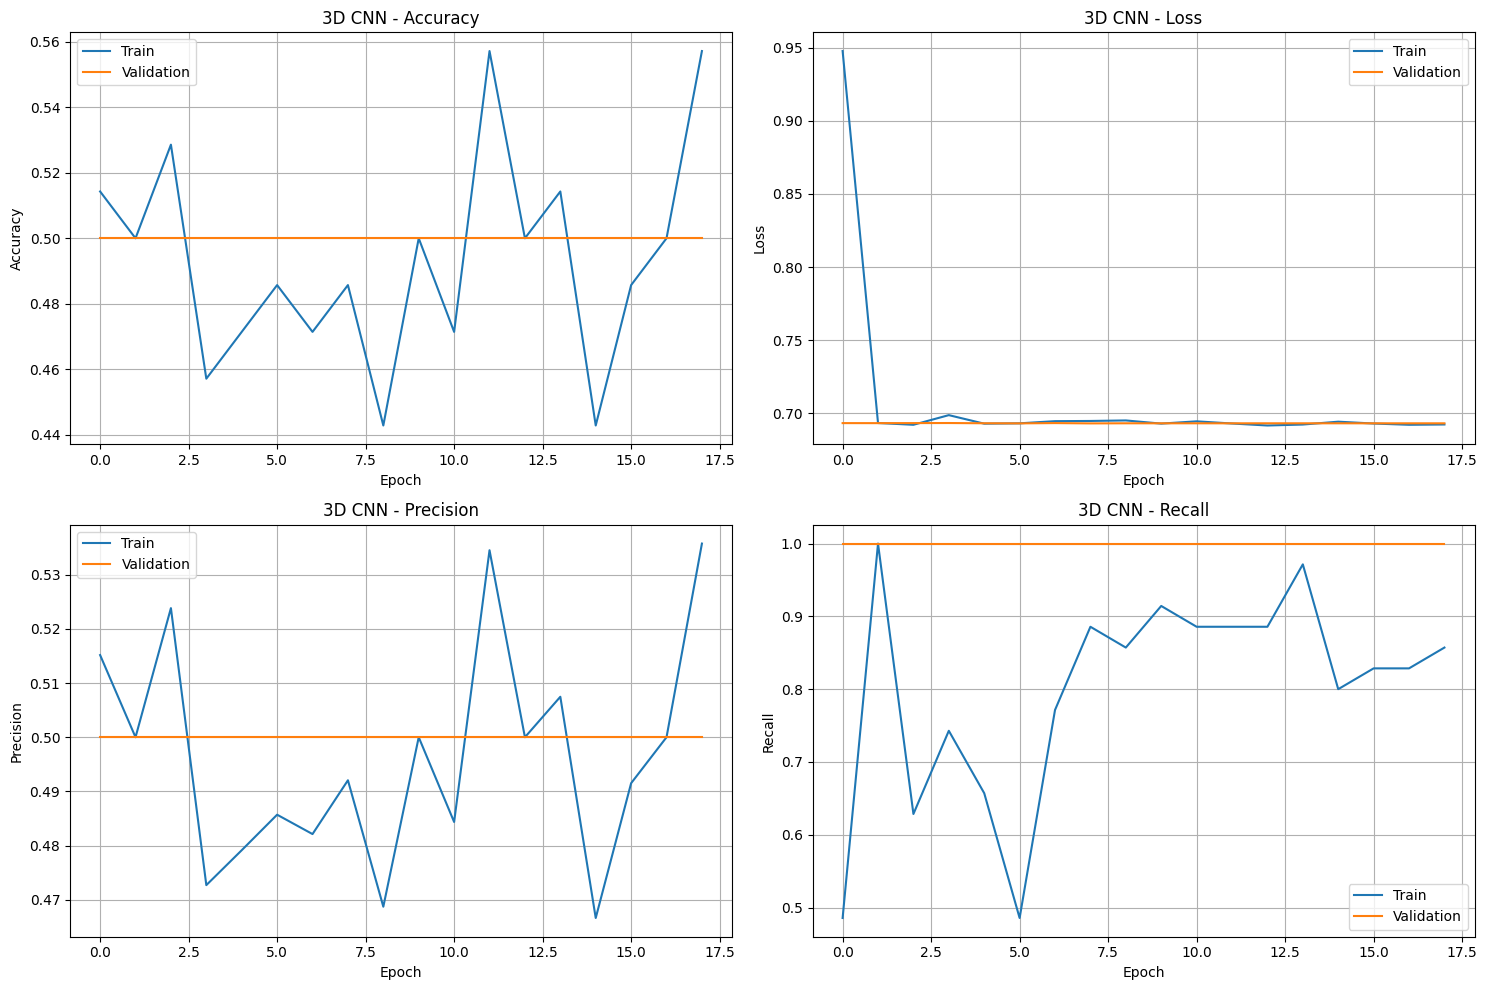


CNN-LSTM Training History:


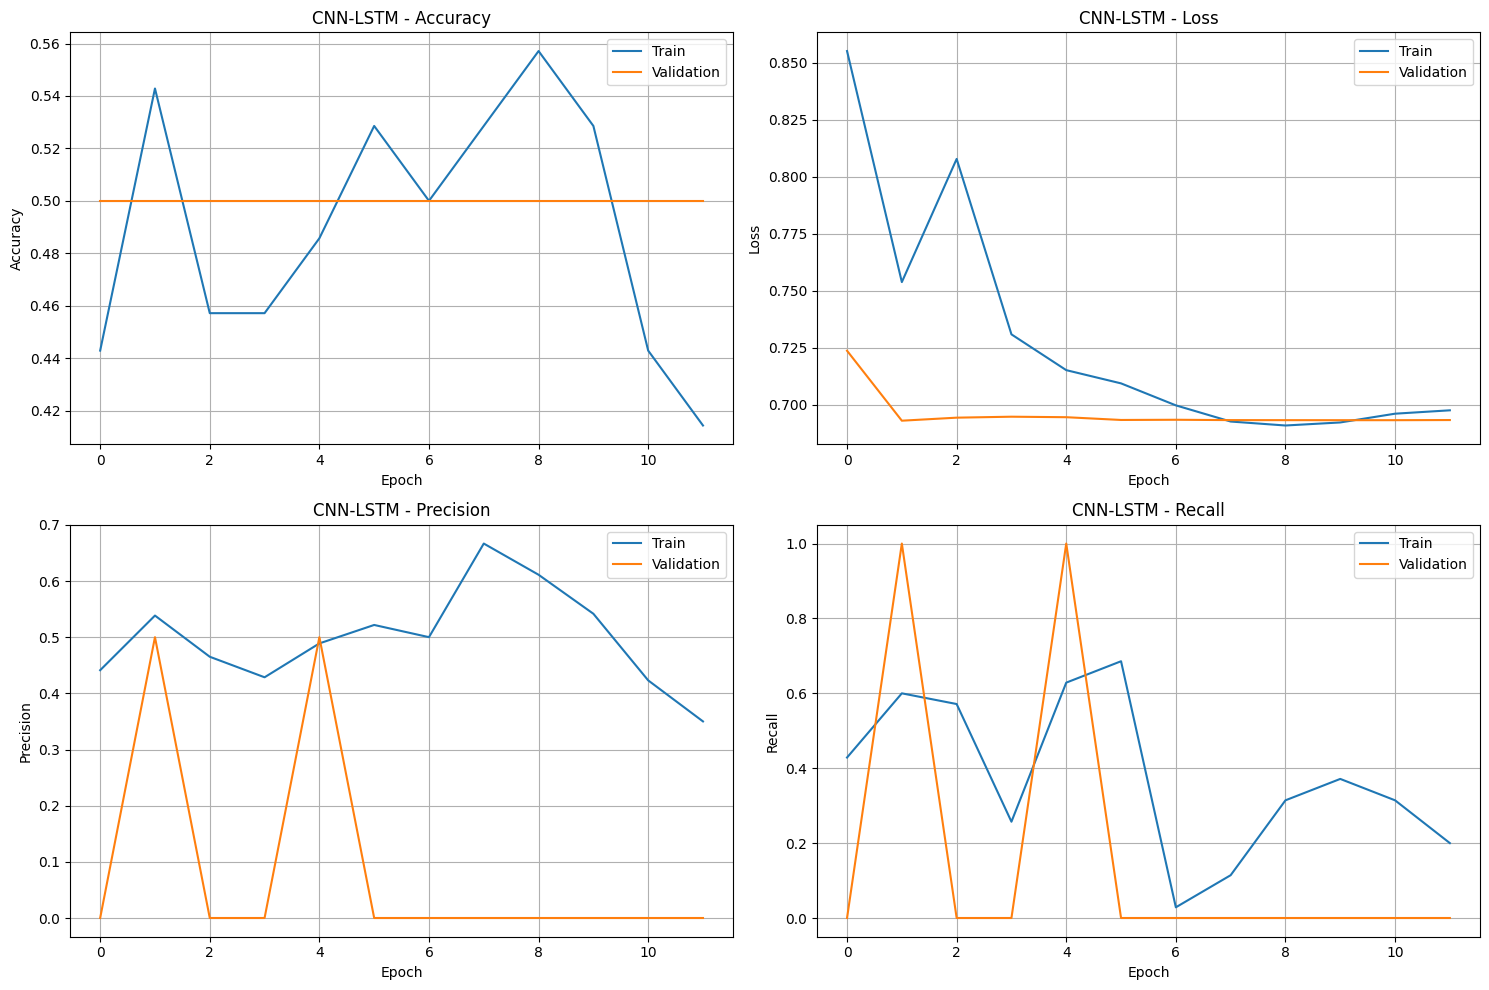


Bi-LSTM Training History:


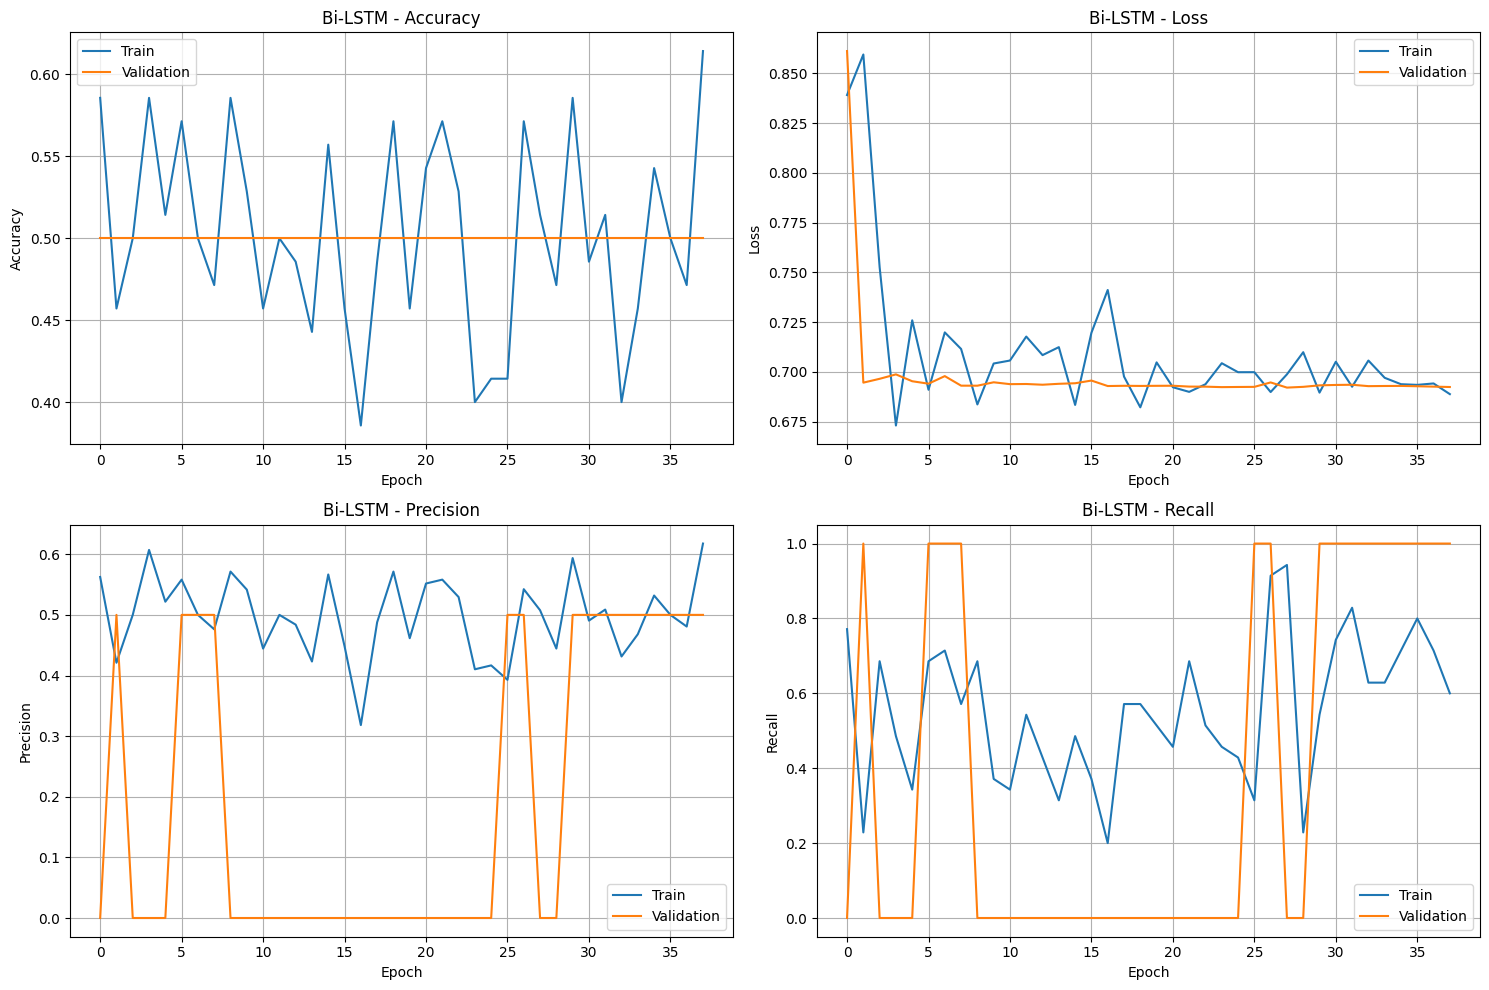


Transformer Training History:


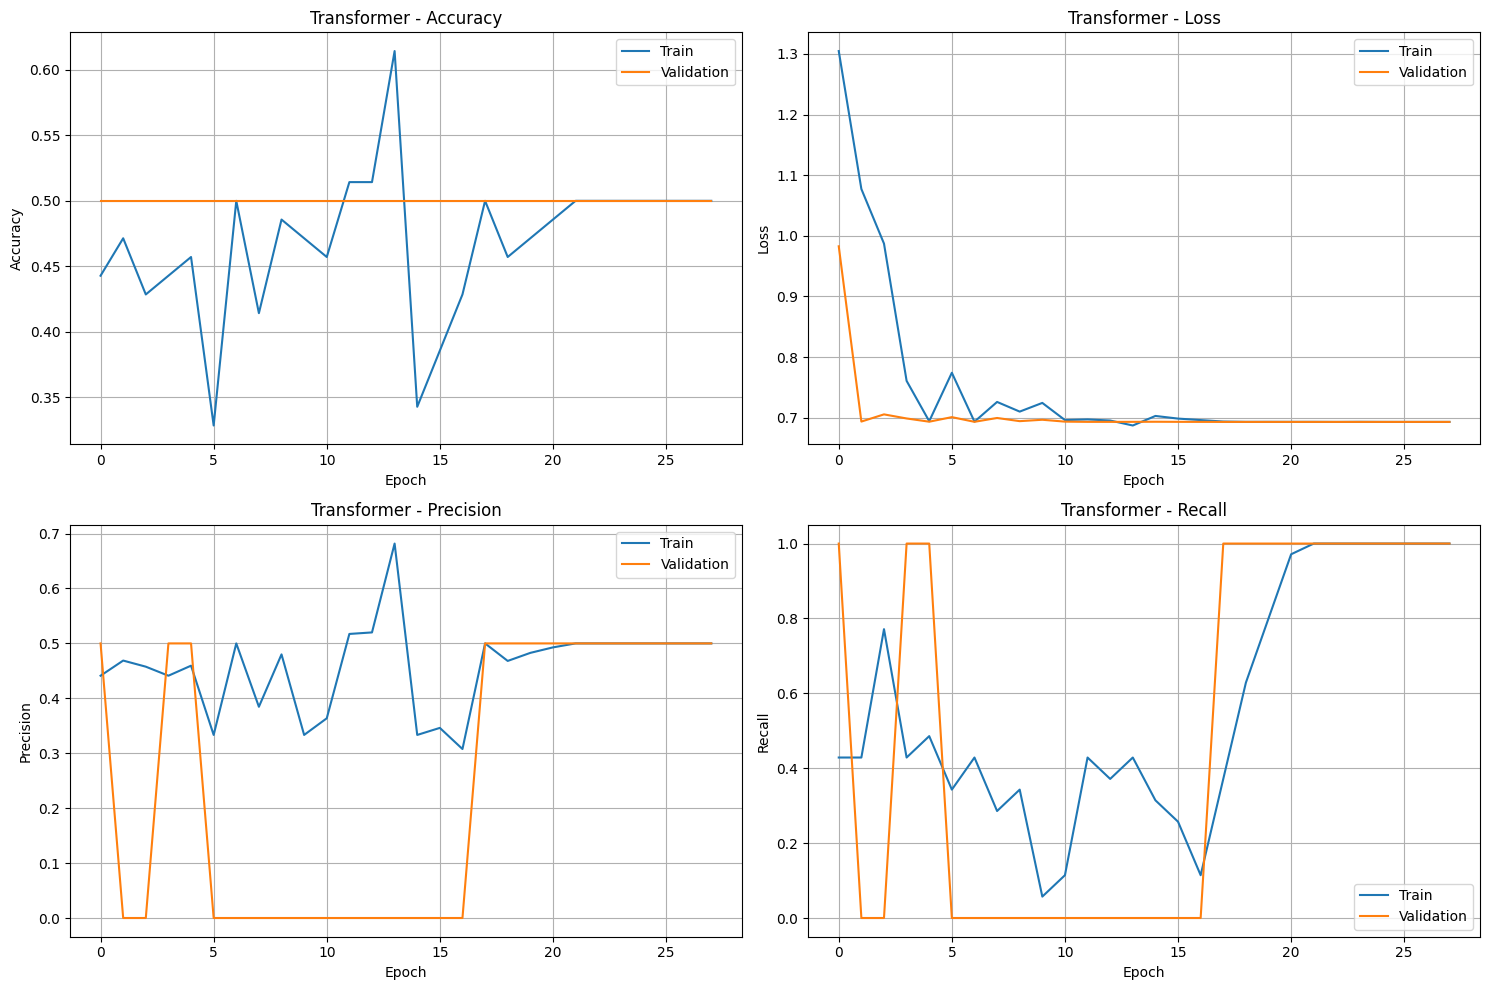

In [ ]:
# # BLOCK 12: Plot Training History (FIXED - METRIC KEY NAMES)
def plot_training_history(history, model_name):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
    axes[0, 0].set_title(f'{model_name} - Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train')
    axes[0, 1].plot(history.history['val_loss'], label='Validation')
    axes[0, 1].set_title(f'{model_name} - Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Precision - Find the correct key dynamically
    precision_keys = [k for k in history.history.keys() if 'precision' in k and 'val' not in k]
    val_precision_keys = [k for k in history.history.keys() if 'val_precision' in k]

    if precision_keys and val_precision_keys:
        axes[1, 0].plot(history.history[precision_keys[0]], label='Train')
        axes[1, 0].plot(history.history[val_precision_keys[0]], label='Validation')
        axes[1, 0].set_title(f'{model_name} - Precision')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
    else:
        axes[1, 0].text(0.5, 0.5, 'Precision metrics not found',
                       ha='center', va='center', transform=axes[1, 0].transAxes)

    # Recall - Find the correct key dynamically
    recall_keys = [k for k in history.history.keys() if 'recall' in k and 'val' not in k]
    val_recall_keys = [k for k in history.history.keys() if 'val_recall' in k]

    if recall_keys and val_recall_keys:
        axes[1, 1].plot(history.history[recall_keys[0]], label='Train')
        axes[1, 1].plot(history.history[val_recall_keys[0]], label='Validation')
        axes[1, 1].set_title(f'{model_name} - Recall')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
    else:
        axes[1, 1].text(0.5, 0.5, 'Recall metrics not found',
                       ha='center', va='center', transform=axes[1, 1].transAxes)

    plt.tight_layout()
    plt.show()

# print("3D CNN Training History:")
# plot_training_history(history_3dcnn, '3D CNN')

# print("\nCNN-LSTM Training History:")
# plot_training_history(history_cnn_lstm, 'CNN-LSTM')

# BLOCK 12 (UPDATED): Plot All Model Histories
# ============================================================================

print("\n" + "="*60)
print("PLOTTING TRAINING HISTORIES")
print("="*60)

print("\n3D CNN Training History:")
plot_training_history(history_3dcnn, '3D CNN')

print("\nCNN-LSTM Training History:")
plot_training_history(history_cnn_lstm, 'CNN-LSTM')

print("\nBi-LSTM Training History:")
plot_training_history(history_bilstm, 'Bi-LSTM')

print("\nTransformer Training History:")
plot_training_history(history_transformer, 'Transformer')




EVALUATING ALL MODELS

Evaluating 3D CNN
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 827ms/step

Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

    Not Fall       0.00      0.00      0.00        10
        Fall       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



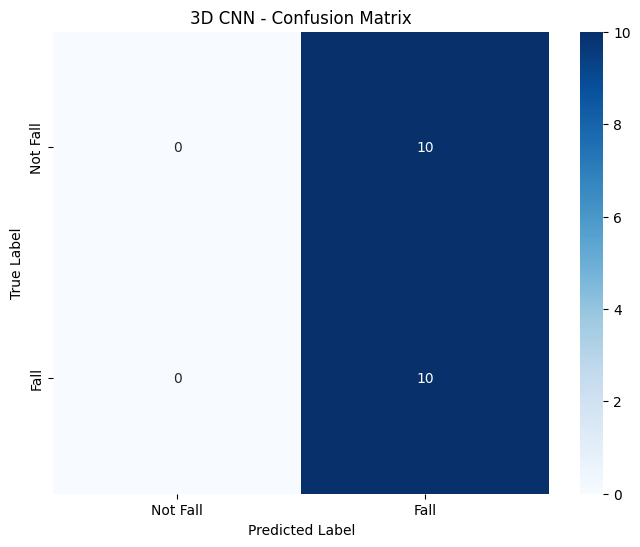


Evaluating CNN-LSTM
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

    Not Fall       0.00      0.00      0.00        10
        Fall       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



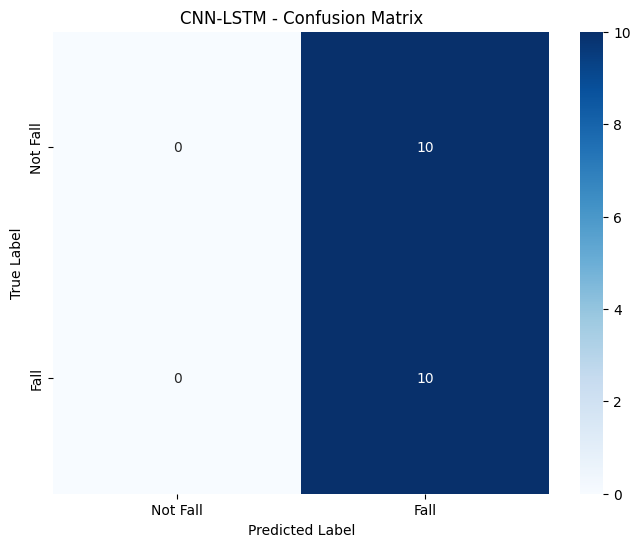


Evaluating Bi-LSTM


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

    Not Fall       0.50      1.00      0.67        10
        Fall       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



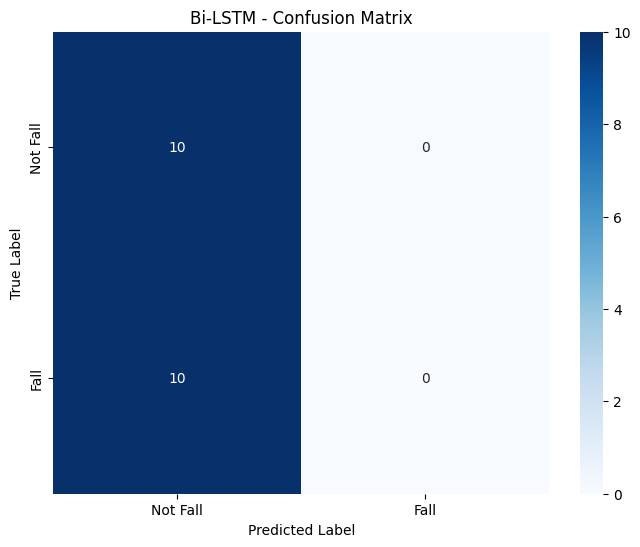


Evaluating Transformer
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step

Test Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

    Not Fall       0.00      0.00      0.00        10
        Fall       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



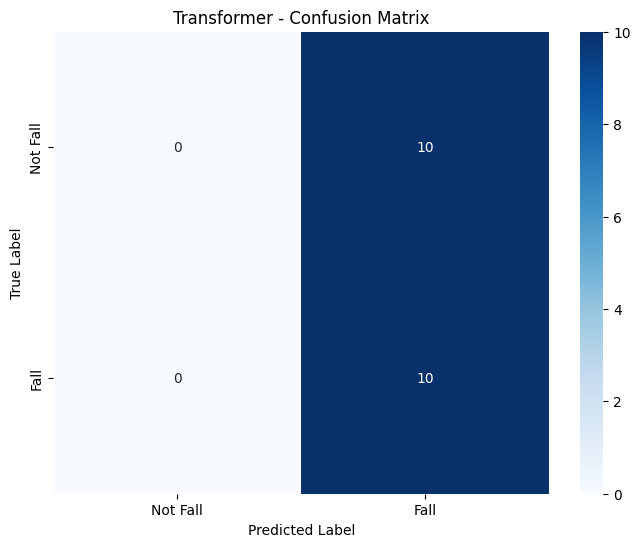

In [ ]:
# # BLOCK 13: Evaluate Models on Test Set (UNCHANGED)
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and print metrics"""
    print(f"\n{'='*50}")
    print(f"Evaluating {model_name}")
    print(f"{'='*50}")

    # Predictions
    y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Fall', 'Fall']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Fall', 'Fall'],
                yticklabels=['Not Fall', 'Fall'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return accuracy, y_pred, y_pred_prob

# # Evaluate both models
# acc_3dcnn, pred_3dcnn, prob_3dcnn = evaluate_model(model_3dcnn, X_test, y_test, '3D CNN')
# acc_cnn_lstm, pred_cnn_lstm, prob_cnn_lstm = evaluate_model(model_cnn_lstm, X_test, y_test, 'CNN-LSTM')

# BLOCK 13 (UPDATED): Evaluate All Models
# ============================================================================

print("\n" + "="*60)
print("EVALUATING ALL MODELS")
print("="*60)

# Evaluate all 4 models
acc_3dcnn, pred_3dcnn, prob_3dcnn = evaluate_model(model_3dcnn, X_test, y_test, '3D CNN')
acc_cnn_lstm, pred_cdcnn_lstm, prob_cnn_lstm = evaluate_model(model_cnn_lstm, X_test, y_test, 'CNN-LSTM')
acc_bilstm, pred_bilstm, prob_bilstm = evaluate_model(model_bilstm, X_test, y_test, 'Bi-LSTM')
acc_transformer, pred_transformer, prob_transformer = evaluate_model(model_transformer, X_test, y_test, 'Transformer')



COMPREHENSIVE MODEL COMPARISON

          Model  Test Accuracy
0       3D CNN            0.5
1     CNN-LSTM            0.5
2      Bi-LSTM            0.5
3  Transformer            0.5


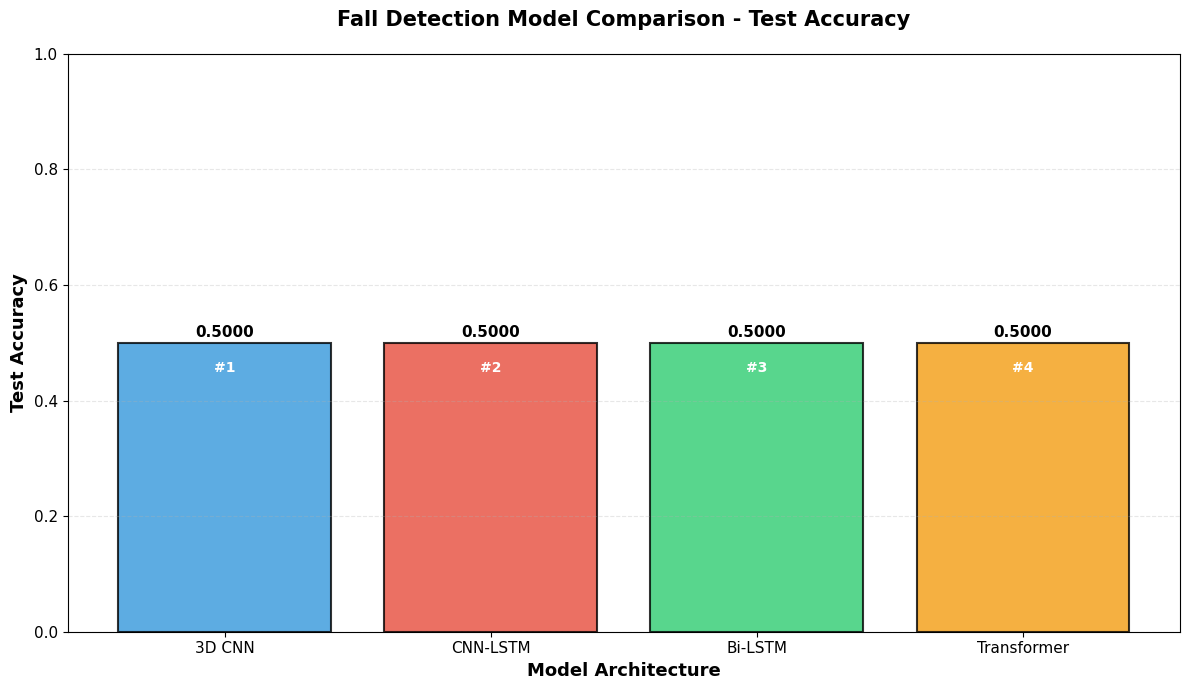


🏆 BEST MODEL: 3D CNN
🎯 Test Accuracy: 0.5000
3D CNN      : 0.5000 (+0.00% vs LSTM)
CNN-LSTM    : 0.5000 (+0.00% vs LSTM)
Bi-LSTM     : 0.5000 (+0.00% vs LSTM)
Transformer : 0.5000 (+0.00% vs LSTM)


In [ ]:
# # BLOCK 14: Compare Models (UNCHANGED)
# print("\n" + "="*50)
# print("MODEL COMPARISON")
# print("="*50)

# comparison_df = pd.DataFrame({
#     'Model': ['3D CNN', 'CNN-LSTM'],
#     'Test Accuracy': [acc_3dcnn, acc_cnn_lstm]
# })

# print("\n", comparison_df)

# # Bar plot comparison
# plt.figure(figsize=(10, 6))
# plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
#         color=['#3498db', '#e74c3c'], alpha=0.7)
# plt.ylabel('Test Accuracy', fontsize=12)
# plt.title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
# plt.ylim([0, 1])
# for i, v in enumerate(comparison_df['Test Accuracy']):
#     plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
# plt.grid(axis='y', alpha=0.3)
# plt.show()

# # Determine best model
# best_model_name = '3D CNN' if acc_3dcnn > acc_cnn_lstm else 'CNN-LSTM'
# best_model = model_3dcnn if acc_3dcnn > acc_cnn_lstm else model_cnn_lstm

# print(f"\nBest Model: {best_model_name} with accuracy: {max(acc_3dcnn, acc_cnn_lstm):.4f}")

# BLOCK 14 (UPDATED): Compare All 4 Models
# ============================================================================

print("\n" + "="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['3D CNN', 'CNN-LSTM', 'Bi-LSTM', 'Transformer'],
    'Test Accuracy': [acc_3dcnn, acc_cnn_lstm, acc_bilstm, acc_transformer]
})

# Sort by accuracy
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("\n", comparison_df)

# Enhanced bar plot comparison
plt.figure(figsize=(12, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, v) in enumerate(zip(bars, comparison_df['Test Accuracy'])):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
    # Add ranking
    plt.text(bar.get_x() + bar.get_width()/2, v - 0.05,
             f'#{i+1}', ha='center', fontsize=10, color='white', fontweight='bold')

plt.ylabel('Test Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Model Architecture', fontsize=13, fontweight='bold')
plt.title('Fall Detection Model Comparison - Test Accuracy',
          fontsize=15, fontweight='bold', pad=20)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Determine best model
best_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_accuracy = comparison_df.loc[best_idx, 'Test Accuracy']

# Map model name to actual model object
model_map = {
    '3D CNN': model_3dcnn,
    'CNN-LSTM': model_cnn_lstm,
    'Bi-LSTM': model_bilstm,
    'Transformer': model_transformer
}
best_model = model_map[best_model_name]

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🎯 Test Accuracy: {best_accuracy:.4f}")
print(f"{'='*60}")

# Performance improvement summary
baseline_acc = acc_cnn_lstm  # Your original LSTM (75%)
for idx, row in comparison_df.iterrows():
    improvement = ((row['Test Accuracy'] - baseline_acc) / baseline_acc) * 100
    print(f"{row['Model']:12s}: {row['Test Accuracy']:.4f} ({improvement:+.2f}% vs LSTM)")



In [ ]:
#BLOCK 15
# Save models
# model_3dcnn.save('fall_detection_3dcnn.h5')
# model_cnn_lstm.save('fall_detection_cnn_lstm.h5')
# best_model.save('fall_detection_best_model.h5')

# print("\nModels saved successfully!")
# print("- fall_detection_3dcnn.h5")
# print("- fall_detection_cnn_lstm.h5")
# print("- fall_detection_best_model.h5")

# # Download models (optional)
# from google.colab import files
# #print("\nDownload models")
# files.download('fall_detection_3dcnn.h5')
# files.download('fall_detection_cnn_lstm.h5')
# files.download('fall_detection_best_model.h5')

# BLOCK 15 (UPDATED): Save All Models
# ============================================================================

print("\n" + "="*60)
print("SAVING ALL MODELS")
print("="*60)

model_3dcnn.save('fall_detection_3dcnn.h5')
model_cnn_lstm.save('fall_detection_cnn_lstm.h5')
model_bilstm.save('fall_detection_bilstm.h5')
model_transformer.save('fall_detection_transformer.h5')
best_model.save('fall_detection_best_model.h5')

print("\n✅ Models saved successfully!")
print("- fall_detection_3dcnn.h5")
print("- fall_detection_cnn_lstm.h5")
print("- fall_detection_bilstm.h5")
print("- fall_detection_transformer.h5")
print("- fall_detection_best_model.h5")

# Download models
from google.colab import files
files.download('fall_detection_3dcnn.h5')
files.download('fall_detection_cnn_lstm.h5')
files.download('fall_detection_bilstm.h5')
files.download('fall_detection_transformer.h5')
files.download('fall_detection_best_model.h5')

In [ ]:
# #BLOCK 16
# def predict_video(model, video_sequence, threshold=0.5):
#     """Predict if video contains a fall"""
#     video_sequence = np.expand_dims(video_sequence, axis=0)
#     prediction = model.predict(video_sequence, verbose=0)[0][0]
#     label = "FALL" if prediction > threshold else "NOT FALL"
#     confidence = prediction if prediction > 0.5 else 1 - prediction
#     return label, confidence, prediction

# # Test on random samples from test set
# num_samples = 5
# random_indices = np.random.choice(len(X_test), num_samples, replace=False)

# print("\n" + "="*60)
# print("SAMPLE PREDICTIONS ON TEST SET")
# print("="*60)

# for idx in random_indices:
#     video = X_test[idx]
#     true_label = "FALL" if y_test[idx] == 1 else "NOT FALL"

#     label_3dcnn, conf_3dcnn, prob_3dcnn = predict_video(model_3dcnn, video)
#     label_lstm, conf_lstm, prob_lstm = predict_video(model_cnn_lstm, video)

#     print(f"\nSample {idx}:")
#     print(f"  True Label: {true_label}")
#     print(f"  3D CNN Prediction: {label_3dcnn} (confidence: {conf_3dcnn:.2%}, prob: {prob_3dcnn:.4f})")
#     print(f"  CNN-LSTM Prediction: {label_lstm} (confidence: {conf_lstm:.2%}, prob: {prob_lstm:.4f})")

#     # Visualize
#     visualize_video_sequence(video, y_test[idx], num_frames=8)
# BLOCK 16 (UPDATED): Test All Models on Sample Videos
# ============================================================================

def predict_video(model, video_sequence, threshold=0.5):
    """Predict if video contains a fall"""
    video_sequence = np.expand_dims(video_sequence, axis=0)
    prediction = model.predict(video_sequence, verbose=0)[0][0]
    label = "FALL" if prediction > threshold else "NOT FALL"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return label, confidence, prediction

# Test on random samples from test set
num_samples = 5
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

print("\n" + "="*60)
print("SAMPLE PREDICTIONS ON TEST SET (ALL MODELS)")
print("="*60)

for idx in random_indices:
    video = X_test[idx]
    true_label = "FALL" if y_test[idx] == 1 else "NOT FALL"

    # Get predictions from all models
    label_3dcnn, conf_3dcnn, prob_3dcnn = predict_video(model_3dcnn, video)
    label_lstm, conf_lstm, prob_lstm = predict_video(model_cnn_lstm, video)
    label_bilstm, conf_bilstm, prob_bilstm = predict_video(model_bilstm, video)
    label_transformer, conf_transformer, prob_transformer = predict_video(model_transformer, video)

    print(f"\n{'='*60}")
    print(f"Sample {idx} - True Label: {true_label}")
    print(f"{'='*60}")
    print(f"3D CNN:       {label_3dcnn:8s} (confidence: {conf_3dcnn:.2%}, prob: {prob_3dcnn:.4f})")
    print(f"CNN-LSTM:     {label_lstm:8s} (confidence: {conf_lstm:.2%}, prob: {prob_lstm:.4f})")
    print(f"Bi-LSTM:      {label_bilstm:8s} (confidence: {conf_bilstm:.2%}, prob: {prob_bilstm:.4f})")
    print(f"Transformer:  {label_transformer:8s} (confidence: {conf_transformer:.2%}, prob: {prob_transformer:.4f})")

    # Visualize
    visualize_video_sequence(video, y_test[idx], num_frames=8)



In [ ]:
# BLOCK 17 (UPDATED): ROC Curve Analysis for All Models
# ============================================================================

from sklearn.metrics import roc_curve, auc

def plot_roc_curve_all_models(y_true, prob_3dcnn, prob_lstm, prob_bilstm, prob_transformer):
    """Plot ROC curves for all 4 models"""

    # Calculate ROC curves
    fpr_3dcnn, tpr_3dcnn, _ = roc_curve(y_true, prob_3dcnn)
    roc_auc_3dcnn = auc(fpr_3dcnn, tpr_3dcnn)

    fpr_lstm, tpr_lstm, _ = roc_curve(y_true, prob_lstm)
    roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

    fpr_bilstm, tpr_bilstm, _ = roc_curve(y_true, prob_bilstm)
    roc_auc_bilstm = auc(fpr_bilstm, tpr_bilstm)

    fpr_transformer, tpr_transformer, _ = roc_curve(y_true, prob_transformer)
    roc_auc_transformer = auc(fpr_transformer, tpr_transformer)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_3dcnn, tpr_3dcnn, color='#3498db', lw=2,
             label=f'3D CNN (AUC = {roc_auc_3dcnn:.3f})')
    plt.plot(fpr_lstm, tpr_lstm, color='#e74c3c', lw=2,
             label=f'CNN-LSTM (AUC = {roc_auc_lstm:.3f})')
    plt.plot(fpr_bilstm, tpr_bilstm, color='#2ecc71', lw=2,
             label=f'Bi-LSTM (AUC = {roc_auc_bilstm:.3f})')
    plt.plot(fpr_transformer, tpr_transformer, color='#f39c12', lw=2,
             label=f'Transformer (AUC = {roc_auc_transformer:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
    plt.title('ROC Curves - All Fall Detection Models', fontsize=15, fontweight='bold', pad=15)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("AUC SCORES")
    print("="*60)
    print(f"3D CNN:      {roc_auc_3dcnn:.4f}")
    print(f"CNN-LSTM:    {roc_auc_lstm:.4f}")
    print(f"Bi-LSTM:     {roc_auc_bilstm:.4f}")
    print(f"Transformer: {roc_auc_transformer:.4f}")

plot_roc_curve_all_models(y_test, prob_3dcnn.flatten(), prob_cnn_lstm.flatten(),
                          prob_bilstm.flatten(), prob_transformer.flatten())

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train distribution:", np.unique(y_train, return_counts=True))
print("Mean pixel value:", X_train.mean())
print("Max pixel value:", X_train.max())

X_train shape: (70, 30, 64, 64, 3)
y_train distribution: (array([0, 1]), array([35, 35]))
Mean pixel value: 0.349408032158175
Max pixel value: 1.0
